In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
#log increments over 2 decades
frequency = np.array([1604, 4812, 8020, 12832, 16040, 48120, 80200, 128320, 160400]) 

# voltages ch1 + uncertainties
V1 = np.array([0.28, 0.28, 0.272, 0.2, 0.084, 0.284, 0.284, 0.284, 0.27])
dV1 = np.array([0.004, 0.006, 0.004, 0.004, 0.006, 0.004, 0.006, 0.006, 0.004])

# voltages ch2 + uncertainties
V2 = np.array([0.043, 0.06, 0.0732, 0.089, 0.084, 0.0551, 0.062, 0.055, 0.03]) 
dV2 = np.array([0.01125, 0.019, 0.038, 0.0145, 0.006, 0.0156, 0.0076, 0.012, 0.01]) 

# time delay + uncertainties
delta_T = np.array([240, 50, 32, 16, 0, 6, 3.2, 2, 1.6]) * 1e-6 
d_delta_T = np.array([80, 5, 8, 2, 4, 1, 2, 1, 0.2]) * 1e-6

# lmh
Lm_H = 20 * np.log10(V2 / V1)
print(Lm_H)

# lmh uncertainty propagation
dR_R = np.sqrt((dV1 / V1)**2 + (dV2 / V2)**2)
print(dR_R)
dLm_H = 20 / np.log(10) * dR_R
print(dLm_H)

# phase angle
angle_H = (delta_T * frequency) * 360 
print(angle_H)

# phase angle uncertainty propagation
d_angle_H = (d_delta_T * frequency) * 360 
print(d_angle_H)


[-16.27379152 -13.38013562 -11.40115646  -7.03279978   0.
 -14.24333482 -13.21853301 -14.25911301 -19.08485019]
[0.26201764 0.31739087 0.51933394 0.16414434 0.10101525 0.28347171
 0.12438792 0.21920229 0.33366239]
[2.2758563  2.75682203 4.51087726 1.42573966 0.87740735 2.46220401
 1.08041974 1.90396694 2.89815469]
[138.5856   86.616    92.3904   73.91232   0.      103.9392   92.3904
  92.3904   92.3904 ]
[46.1952   8.6616  23.0976   9.23904 23.0976  17.3232  57.744   46.1952
 11.5488 ]


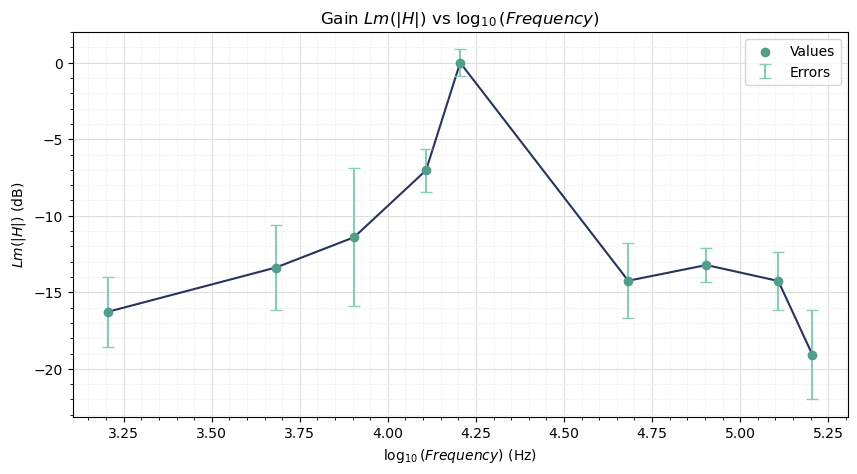

In [29]:
plt.figure(figsize=(10,5))

# Plot
plt.scatter(np.log10(frequency), Lm_H, color="#519E8A", zorder=5, label="Values")
plt.plot(np.log10(frequency), Lm_H, color="#29335C", zorder=3)

#Line of best fit
# plt.plot(np.unique(frequency), np.poly1d(np.polyfit(frequency, Lm_H, 1))(np.unique(frequency)), color = "#29335C")

# Error Bars
plt.errorbar(np.log10(frequency), Lm_H, yerr=dLm_H, fmt=",", ecolor="#89ccba", color="#519E8A", capsize=4, zorder=4, label="Errors")
# fmt=line marker, "," is a pixel.
# ecolor is for the error bars, color is for values.
#capsize is the length of the error bar cap.

# Axes, Legends, Title, etc.
plt.title(r"Gain $Lm(|H|)$ vs $\log_{10}(Frequency)$")
plt.xlabel(r"$\log_{10}(Frequency)$ (Hz)")
plt.ylabel(r"$Lm(|H|)$ (dB)")
plt.legend()

# Grids, etc
plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

plt.show()

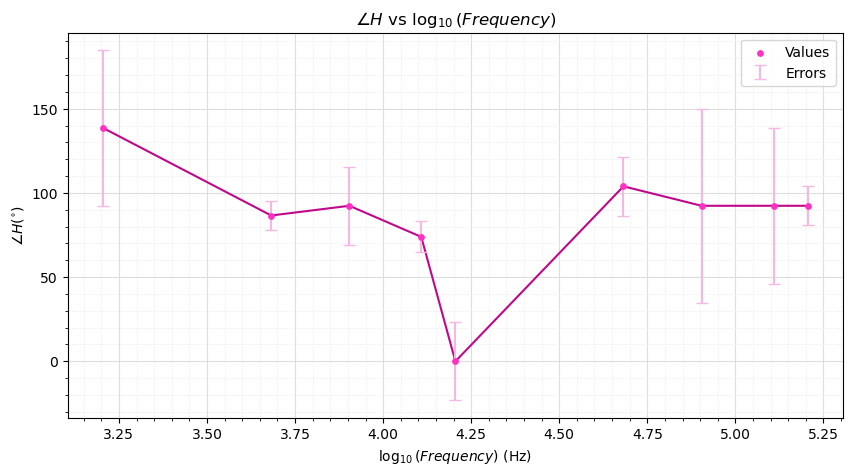

In [43]:
plt.figure(figsize=(10,5))

# Plot
plt.scatter(np.log10(frequency), angle_H, color="#ff30c4", s=15, zorder=5, label="Values")
plt.plot(np.log10(frequency), angle_H, color="#bf088b", zorder=3)

#Line of best fit
# plt.plot(np.unique(frequency), np.poly1d(np.polyfit(frequency, Lm_H, 1))(np.unique(frequency)), color = "#29335C")

# Error Bars
plt.errorbar(np.log10(frequency), angle_H, yerr=d_angle_H, fmt=",", ecolor="#f5b8e3", color="#f5b8e3", capsize=4, zorder=4, label="Errors")
# fmt=line marker, "," is a pixel.
# ecolor is for the error bars, color is for values.
#capsize is the length of the error bar cap.

# Axes, Legends, Title, etc.
plt.title(r"$\angle H$ vs $\log_{10}(Frequency)$")
plt.xlabel(r"$\log_{10}(Frequency)$ (Hz)")
plt.ylabel(r"$\angle H (^{\circ})$")
plt.legend()

# Grids, etc
plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

plt.show()

In [87]:
L = 9.845e-4 
C = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220]) * 1e-6
V2 = np.array([240, 224, 188, 164, 84, 104, 144, 170, 188, 200, 208]) * 1e-3
R = 10

f_0 = 1 / (2 * np.pi * np.sqrt(L * C))
#print(f_0)

angfreq = 2 * np.pi * f_0
print(angfreq)

I = V2 / (np.sqrt(R**2 + ((angfreq * L) - (1 / (angfreq * C)))**2))
print(I)

Q = 1 / (angfreq * R * C)
print(Q)
avgQ = np.average(Q)
print(avgQ, np.std(Q))


[7126.51398828 5039.20636734 4114.49476952 3563.25699414 3187.07394408
 2909.38715268 2693.56910397 2519.60318367 2375.50466276 2253.601598
 2148.72481476]
[0.024  0.0224 0.0188 0.0164 0.0084 0.0104 0.0144 0.017  0.0188 0.02
 0.0208]
[0.7016053  0.49610987 0.40507201 0.35080265 0.31376743 0.28642917
 0.26518188 0.24805493 0.23386843 0.22186708 0.21154196]
0.3394818823839039 0.14103745146712773


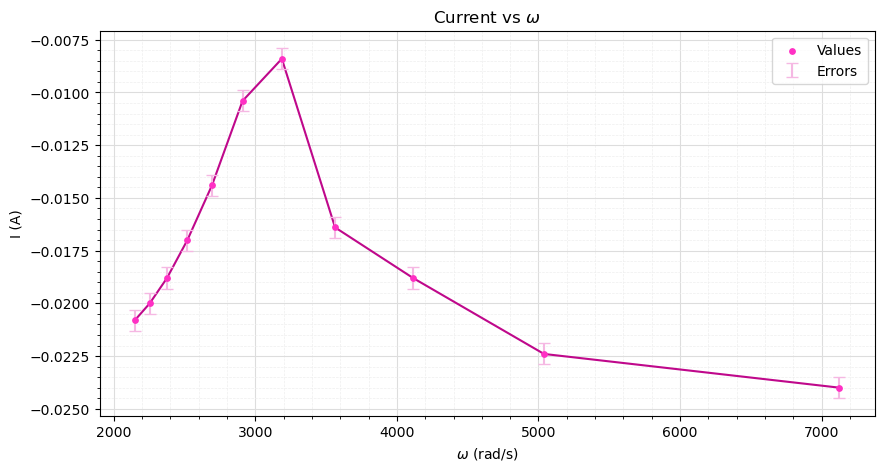

In [82]:
plt.figure(figsize=(10,5))

# Plot
plt.scatter(angfreq, -I, color="#ff30c4", s=15, zorder=5, label="Values")
plt.plot(angfreq, -I, color="#bf088b", zorder=3)

#Line of best fit
# plt.plot(np.unique(frequency), np.poly1d(np.polyfit(frequency, Lm_H, 1))(np.unique(frequency)), color = "#29335C")

# Error Bars
plt.errorbar(angfreq, -I, yerr=0.0005, fmt=",", ecolor="#f5b8e3", color="#f5b8e3", capsize=4, zorder=4, label="Errors")
# fmt=line marker, "," is a pixel.
# ecolor is for the error bars, color is for values.
#capsize is the length of the error bar cap.

# Axes, Legends, Title, etc.
plt.title(r"Current vs $\omega$")
plt.xlabel(r"$\omega$ (rad/s)")
plt.ylabel(r"I (A)")
plt.legend()

# Grids, etc
plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

plt.show()